In [1]:
# Import libraries
import io
import os
import pandas as pd
from IPython.display import display

print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
# Upload the original CSV file in Google Colab
from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise ValueError('No file was uploaded.')

# Select the first uploaded CSV file
csv_files = [name for name in uploaded.keys() if name.lower().endswith('.csv')]
if not csv_files:
    raise ValueError('Please upload a CSV file.')

file_name = csv_files[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f'Loaded file: {file_name}')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
display(df.head())

Saving Market.csv to Market.csv
Loaded file: Market.csv
Rows: 112,457
Columns: 8


,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1/3/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1/4/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1/5/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1/6/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


In [3]:
# Inspect the column structure before encoding
print('Column names:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

print('\nMissing values:')
display(df.isna().sum().to_frame('missing_values'))

if 'Index' not in df.columns:
    raise KeyError("The required categorical column 'Index' was not found.")

print(f"\nUnique values in 'Index': {df['Index'].nunique(dropna=False)}")
display(df['Index'].value_counts(dropna=False).to_frame('row_count'))

Column names:
['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data types:


,dtype
Index,object
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,float64



Missing values:


,missing_values
Index,0
Date,0
Open,2204
High,2205
Low,2206
Close,2207
Adj Close,2213
Volume,2204



Unique values in 'Index': 14


,row_count
Index,
N225,14500
NYA,13948
IXIC,12690
GSPTSE,10776
HSI,8750
GDAXI,8606
SSMI,7830
KS11,6181
TWII,6010


In [4]:
# One-hot encode the Index column
# Using pandas get_dummies creates one binary column per market index.
encoded_df = pd.get_dummies(
    df,
    columns=['Index'],
    prefix='Index',
    dtype='int64'
)

one_hot_columns = [column for column in encoded_df.columns if column.startswith('Index_')]

print(f'Original shape: {df.shape}')
print(f'Encoded shape: {encoded_df.shape}')
print(f'Number of one-hot columns created: {len(one_hot_columns)}')
print('\nOne-hot columns:')
print(one_hot_columns)

display(encoded_df.head())

Original shape: (112457, 8)
Encoded shape: (112457, 21)
Number of one-hot columns created: 14

One-hot columns:
['Index_000001.SS', 'Index_399001.SZ', 'Index_GDAXI', 'Index_GSPTSE', 'Index_HSI', 'Index_IXIC', 'Index_J203.JO', 'Index_KS11', 'Index_N100', 'Index_N225', 'Index_NSEI', 'Index_NYA', 'Index_SSMI', 'Index_TWII']


,Date,Open,High,Low,Close,Adj Close,Volume,Index_000001.SS,Index_399001.SZ,Index_GDAXI,...,Index_HSI,Index_IXIC,Index_J203.JO,Index_KS11,Index_N100,Index_N225,Index_NSEI,Index_NYA,Index_SSMI,Index_TWII
0,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1/3/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,1/4/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1/5/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,1/6/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [5]:
# Validate the encoding
# Every row should have exactly one active Index_* column.
active_categories_per_row = encoded_df[one_hot_columns].sum(axis=1)

print('Rows with exactly one active market-index category:',
      (active_categories_per_row == 1).sum(), '/', len(encoded_df))
print('Rows with an invalid number of active categories:',
      (active_categories_per_row != 1).sum())
print('Missing values after encoding:', int(encoded_df.isna().sum().sum()))

assert (active_categories_per_row == 1).all(), \
    'Validation failed: some rows do not have exactly one Index category.'
assert 'Index' not in encoded_df.columns, \
    "Validation failed: the original 'Index' column still exists."

print('\nEncoding validation passed.')

Rows with exactly one active market-index category: 112457 / 112457
Rows with an invalid number of active categories: 0
Missing values after encoding: 13239

Encoding validation passed.


In [6]:
# Save and download the encoded dataset
output_file = 'Market_categorical_encoded.csv'
encoded_df.to_csv(output_file, index=False)

print(f'Saved: {output_file}')
print(f'File size: {os.path.getsize(output_file):,} bytes')

files.download(output_file)

Saved: Market_categorical_encoded.csv
File size: 11,506,677 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

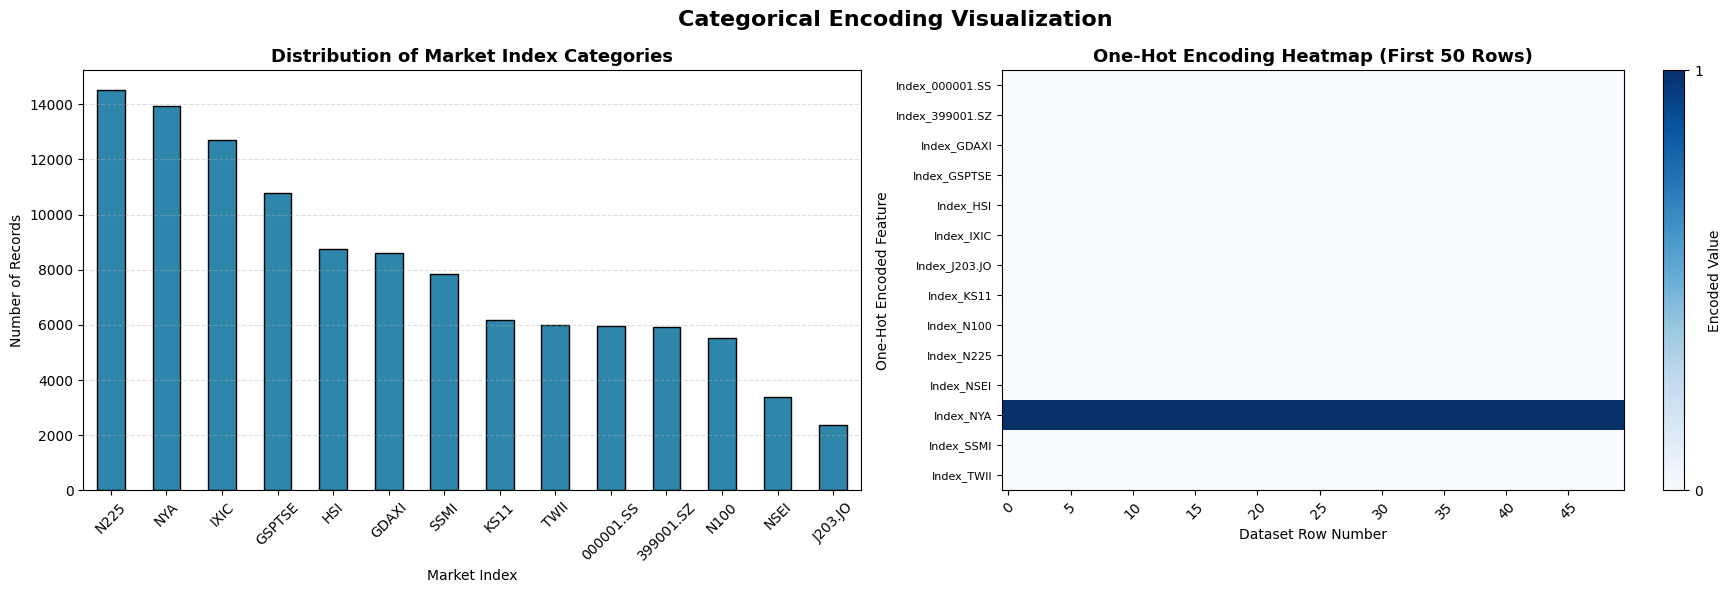

Visualization completed successfully.
Interpretation: each row in the heatmap has one active (1) Index category and zeros for the remaining categories.


In [7]:
import matplotlib.pyplot as plt

# Prepare the category counts using the original Index column
category_counts = df['Index'].value_counts().sort_values(ascending=False)

# Use a readable figure size for Google Colab and reports
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: frequency of each market-index category
category_counts.plot(
    kind='bar',
    ax=axes[0],
    color='#2E86AB',
    edgecolor='black'
)
axes[0].set_title('Distribution of Market Index Categories', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Market Index')
axes[0].set_ylabel('Number of Records')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Chart 2: heatmap-style view of the one-hot encoded values
sample_size = min(50, len(encoded_df))
encoded_sample = encoded_df[one_hot_columns].head(sample_size).T

image = axes[1].imshow(
    encoded_sample.values,
    aspect='auto',
    interpolation='nearest',
    cmap='Blues',
    vmin=0,
    vmax=1
)
axes[1].set_title(
    f'One-Hot Encoding Heatmap (First {sample_size} Rows)',
    fontsize=13,
    fontweight='bold'
)
axes[1].set_xlabel('Dataset Row Number')
axes[1].set_ylabel('One-Hot Encoded Feature')
axes[1].set_yticks(range(len(one_hot_columns)))
axes[1].set_yticklabels(one_hot_columns, fontsize=8)
axes[1].set_xticks(range(0, sample_size, max(1, sample_size // 10)))
axes[1].set_xticklabels(
    range(0, sample_size, max(1, sample_size // 10)),
    rotation=45
)
fig.colorbar(image, ax=axes[1], ticks=[0, 1], label='Encoded Value')

plt.suptitle('Categorical Encoding Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('Visualization completed successfully.')
print('Interpretation: each row in the heatmap has one active (1) Index category and zeros for the remaining categories.')